# Pre-Requisite Knowledge

Some mathematical knowledge that may help in finding the optimal $\alpha$ value for the convex hull.

## 1. Affine Combination

### Definition
An **affine combination** of $x_1,\ldots,x_n$ is a *linear combination*  $$\sum_{i=1}^n\alpha_i\cdot x_i=  \alpha_1 x_1+\alpha_2 x_2 +\ldots + \alpha_nx_n$$ such that it satisfies $$ \sum_{i=1}^n\alpha_i = 1$$ where $x_i$ are elements (vectors) or a vector space over a field $\mathcal{K}$, and coefficients $\alpha_i$ are elements of $\mathcal{K}$.

(Reference: https://en.wikipedia.org/wiki/Affine_combination)

### Geometric Meaning
This simple rule $\displaystyle\sum_{i=1}^n\alpha_i=1$ ensures the combination is **independent of the origin** of the **coordinate system**.

1. **Linear Combinations**: 
    - Depend on the origin. 
    - If you move the origin, the result of a linear combination changes. 
    - They define vectors and vector spaces.

2. **Affine Combinations**: 
    - Do not depend on the origin. 
    - If you move the origin, the point defined by an affine combination stays fixed. 
    - They define points and affine spaces.

### Example
Imagine two points, $A$ and $B$, on a line. The affine combination $\alpha A + \beta B$ (where $\alpha + \beta = 1$) represents every single point on the line connecting $A$ and $B$.
- If $\alpha=1, \beta=0,$ you're at point $A$.
- If $\alpha=0, \beta=1,$ you're at point $B$.
- If $\alpha=0.5, \beta=0.5,$ you're at the exact midpoint between $A$ and $B$.
- If $\alpha=0.75, \beta=0.25,$ you're 75% of the way from $B$ to $A$.

---

## 2. Convex Sets

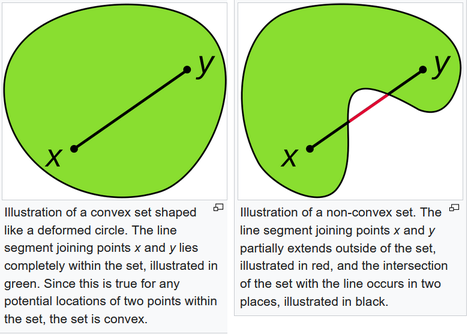

### Definition

Let $\mathcal{S}$ be a vector space (or an affine space) over $\mathbb{R}$, or more generally, over some ordered field $\mathbb{F}$ (this includes Euclidean spaces, which are affine spaces). A subset $\mathcal{C}$ of $\mathcal{S}$ is **convex** if, for all $x$ and $y$ in $\mathcal{C}$, the **line segment connecting** $x$ and $y$ is **included in** $\mathcal{C}$.

This means that the **affine combination** $(1 − t)x + ty$ **belongs to** $\mathcal{C}, \ \forall \ x,y \in \mathcal{C}$ and $t \in [0, 1]$. This implies that convexity is invariant under affine transformations (any transformation that can be expressed as a linear transformation, e.g. rotation, scaling, shearing, reflection — followed by a translation). Further, it implies that a convex set in a real or complex topological vector space is path-connected (and therefore also connected). 

In English, a **set of points is convex** if it *contains every line segment between two points* in the set. For example, a solid cube is a convex set, but anything that is hollow or has an indent, such as a crescent shape, is not convex.

---

## 3. Polyhedron



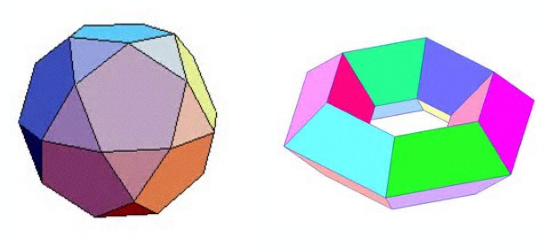

### Definition
1. Region of space whose boundary consists of vertices, edges and faces.
2. Faces intersect properly.
3. Neighborhood of any point on $\mathcal{P}$ is homeomorphic to a disk.
4. Surface of $\mathcal{P}$ is connected.

### Explanation

1. Region of space whose boundary consists of *vertices, edges and faces*.
    - **Examples**: A cube, a pyramid, a prism.
    - **Non-Examples**: A sphere, a cone.
2. Faces *intersect properly*.
    - **Two faces** can only meet at a single edge. (they cannot meet at just a point or overlap in a more complex way)
    - **Three or more faces** can only meet at a single vertex.

    This rule ensures the polyhedron is "well-behaved." It guarantees that the edges and vertices are exactly where we expect them to be.

    - **Example**: In a cube, two squares meet along a full edge.
    - **Non-Example:** Imagine gluing two pyramids together so that one of their triangular faces overlaps only partially.

3. Neighborhood of any point on $\mathcal{P}$ is *homeomorphic* to a disk.
    - **Neighborhood**: The region immediately surrounding a point. Imagine a tiny circle drawn on the surface around that point.
    - **Homeomorphic** to a disk: You can take that tiny circle and "mold" or "stretch" it (without tearing or gluing) into a flat, round disk.

    This condition ensures the polyhedron's surface is smooth and manifold at every point. There are no strange pinches, self-intersections, or boundaries (except for the actual edges of the polyhedron itself).
    - **Examples**
    - On a flat face: A tiny circle is already a flat disk.
    - On a smooth edge: A tiny circle gets "bent" around the edge, but you can still easily flatten it into a disk.
    - At a vertex: If you carefully "flatten" the corner of a cube, the three faces become three sectors of a disk meeting at a point. (requires condition that at a corner, the immediate surroundings can be flattened out)
    - **Non-Example**: Imagine two pyramids glued together at a single, sharp needle-like point. The immediate area around that needle point could not be flattened into a nice disk—it would be like two disks pinched together. 

4. Surface of $\mathcal{P}$ is connected.
    - **Connected**: The surface is all in one piece. 
    - You can travel from any point on the surface to any other point without having to leave the surface.

    This rule excludes collections of separate polyhedra. A single cube is connected. Two cubes sitting on a table, not touching each other, form a surface that is not connected.

### Convex Polyhedron

From our definition of convex sets, $\mathcal{P}$ is convex if for any $p,q \in \mathcal{P}$, the segment $pq$ lies entirely in $\mathcal{P}.$

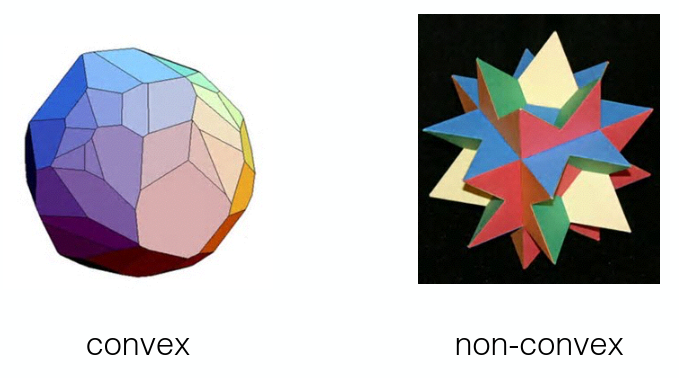

---

## 4. Convex Hull

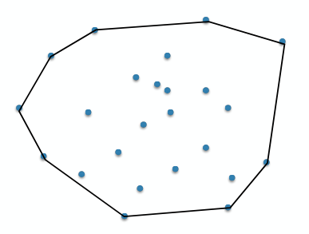
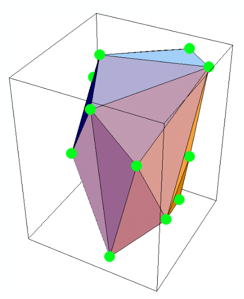

### Definition
In geometry, the **convex hull** (convex envelope or convex closure) of a shape is the *smallest convex set* that *contains it*. 

A set of points in a Euclidean space is defined to be convex if it contains the line segments connecting each pair of its points. The convex hull of a given set $X$ may be defined as:
1. The (unique) minimal convex set containing $X$.
2. The intersection of all convex sets containing $X$.
3. The set of all convex combinations of points in $X$.
4. The union of all simplices with vertices in $X$.


For a **bounded subset** of 2D space (plane), the convex hull may be **visualized** as the **shape enclosed by a rubber band stretched around the subset** (i.e. polygon). 

For a **bounded subset** of 3D space, the convex hull can be **visualized** as the s**hape enclosed a shrink-wrap sheet stretched around the subset** (i.e. polyhedron).

---

# Convex Hull Modelling

## Preprocessing

Import necessary libraries and change matplotlib settings

In [2]:
# Import necessary libraries
import matplotlib.pyplot as plt
# import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Polygon
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.spatial import ConvexHull

# Matplotlib settings
plt.rcParams['text.usetex'] = False
plt.rcParams['font.serif'] = [ "Liberation Serif", "Times New Roman"]
plt.rcParams['font.family'] = "serif"
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['figure.dpi'] = 100

Create project_root PATH and add it to modules PATH

In [3]:
import os, sys

# Go up THREE levels (project root directory)
project_root = os.path.dirname(os.path.dirname(os.path.dirname(os.getcwd())))

# Append the new path to sys.path
if project_root not in sys.path:
    sys.path.append(project_root)
    print("Project root added to sys.path")
else:
    print("Project root already in sys.path")

Project root added to sys.path


Process molecule and oxygen midpoints data

In [4]:
# Import module
from utils import gro_processing as gp

# Data directory can be accessed due to root PATH we set previously
file = os.path.join(project_root, 'data/npt-HK4.gro')

# Extracts data from .gro file into DataFrame (unsorted)
data, title, num_atoms, box_dimensions = gp.read_gro(file) 

# Parameter
box_length = box_dimensions[0]

# Create multi-index DataFrame (sorted)
df_gro = gp.dataframe_gro(data, box_length, positions=True, velocities=False, oxygen_midpoints=False)

# Dataframe of all atoms
# df_gro

Creating simple 2D closed polygon

## 1. Whole Molecule

### Random Points 2-D

In [ ]:
# Generate 30 random points in 2D
rng = np.random.default_rng(seed=40)
points = rng.random((30, 2))

# Calculate the convex hull
hull = ConvexHull(points)

# Checking
# print(f'{hull.simplices=}') # Hull simplices (edges in 2D)
# print(f'{hull.vertices=}')  # Hull vertices

# Understand the structure of hull object
# print(f'Points:\n{points[:3]}\n')
# print(f'Hull simplices:\n{hull.simplices[:3]}\n')
# print(f'points[hull.simplices]:\n{points[hull.simplices][:3]}\n')

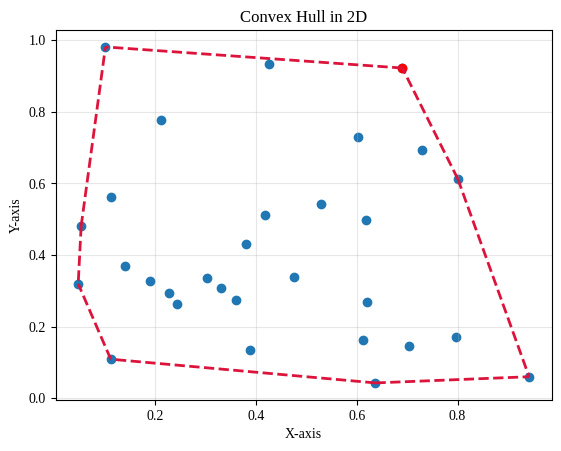

In [8]:
# Create figure and axis
fig, ax = plt.subplots()
ax.set_title(r'Convex Hull in 2D')
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.grid(True, alpha=0.3)

# Scatter of data points
ax.scatter(points[:,0], points[:,1])
# Highlighting the first vertex
ax.scatter(points[hull.vertices[0],0], points[hull.vertices[0],1], color='red')

# Drawing convex hull using simplex
for simplex in hull.simplices:
    plt.plot(points[simplex, 0], points[simplex, 1], ls='--', color='crimson', linewidth=2)

# Drawing convex hull using vertices
# hull_patch = Polygon(points[hull.vertices], closed=True, fill=None, edgecolor='r', linewidth=2)
# ax.add_patch(hull_patch)


# Adjust the plot view to see the whole patch
ax.autoscale_view()
plt.show()

### Random Points 3-D

In [9]:
# Create random rng seed
rng = np.random.default_rng(seed=42)

# Generate 30 random 3D points and compute the convex hull
points = rng.random((30, 3))
hull = ConvexHull(points)

# Create hull_faces for Poly3DCollection
hull_faces = []
for simplex in hull.simplices:
    hull_faces.append(points[simplex]) # Each simplex is a triangle face

# Optional: Color faces based on their index
colors = plt.cm.viridis(np.linspace(0, 1, len(hull.simplices)))

# Create a poly3d collection for plotting
poly3d = Poly3DCollection(hull_faces,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor=colors)


# Checking
# print(f'{hull.simplices=}') # Hull simplices (edges in 3D)
# print(f'{hull.vertices=}')  # Hull vertices

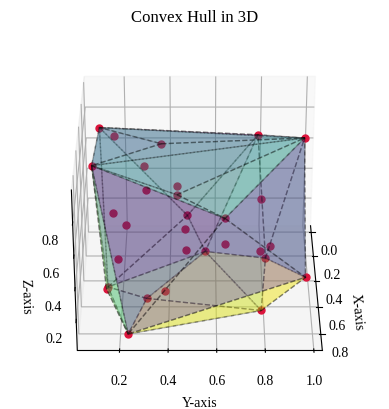

In [10]:
# Create figure and axis
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.set_title(r'Convex Hull in 3D')
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.grid(True, alpha=0.3)

# Scatter of original points
ax.plot(points[:,0],
        points[:,1],
        points[:,2],
        marker='o',
        ls='none',
        color='crimson',
        markersize=5)

# Create the Poly3DCollection and add it to the plot
ax.add_collection3d(poly3d)

# Create camera rotation function
def rotate(angle):
    ax.view_init(elev=30, azim=angle)
    return fig,

# Create animation
ani = FuncAnimation(fig, rotate, frames=np.arange(0, 362, 2), interval=100, blit=True)
ani.save('./animation/[01]CH_Random_Points.mp4', writer='ffmpeg', fps=30)

# Adjust the plot view to see the whole patch
# ax.autoscale_view()
plt.show()

### Real Molecule 3-D

In [11]:
# Obtain the 100th molecule
df_molecule_100 = df_gro.loc[(100, slice(None))]
# display(df_molecule_100)

# Create vertices array of 100th molecule
points_100 = df_molecule_100[['x', 'y', 'z']].to_numpy()

# Create convex hull
hull = ConvexHull(points_100, qhull_options='Qx') # Qx to avoid precision error

# Create hull_faces for Poly3DCollection
hull_faces = []
for simplex in hull.simplices:
    hull_faces.append(points_100[simplex]) # Each simplex is a triangle face

# Optional: Color faces based on their index
colors = plt.cm.viridis(np.linspace(0, 1, len(hull.simplices)))

# Create a poly3d collection for plotting
poly3d = Poly3DCollection(hull_faces,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor=colors)

# Checking
print(f'Number of atoms in molecule 100: {len(points_100)}')
print("Number of convex hull vertices:", len(hull.vertices))
print(f'Number of convex hull faces: {len(hull.simplices)}')
print(f'Area of convex hull: {hull.area:.4f}')
print(f'Volume of convex hull: {hull.volume:.4f}')

Number of atoms in molecule 100: 84
Number of convex hull vertices: 21
Number of convex hull faces: 38
Area of convex hull: 4.1084
Volume of convex hull: 0.4134


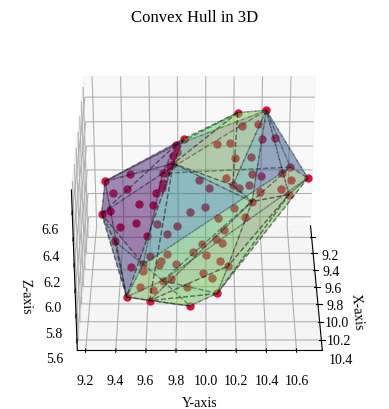

In [12]:
# Create figure and axis
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.set_title(r'Convex Hull in 3D')
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.grid(True, alpha=0.3)

# Scatter of original points
ax.plot(points_100[:,0],
        points_100[:,1],
        points_100[:,2],
        marker='o',
        ls='none',
        color='crimson',
        markersize=5)

# Create the Poly3DCollection and add it to the plot
ax.add_collection3d(poly3d)

# Create camera rotation function
def rotate(angle):
    ax.view_init(elev=30, azim=angle)
    return fig,

# Create animation
ani = FuncAnimation(fig, rotate, frames=np.arange(0, 362, 2), interval=100, blit=True)
ani.save('./animation/[02]CH_Molecule_100.mp4', writer='ffmpeg', fps=30)

# Adjust the plot view to see the whole patch
# ax.autoscale_view()
plt.show()

## 2. Break Molecule into Pieces

In [13]:
import inspect

# Helper functions
def info_hull(hull):
    # Get the calling frame and find the variable name
    frame = inspect.currentframe().f_back
    for var_name, var_val in frame.f_locals.items():
        if var_val is hull:
            print(f'------ {var_name} ------')
            break
    else:
        print(f'Current hull: unknown variable')
        
    print("Number of convex hull vertices:", len(hull.vertices))
    print(f'Number of convex hull faces: {len(hull.simplices)}')
    print(f'Area of convex hull: {hull.area:.4f}')
    print(f'Volume of convex hull: {hull.volume:.4f}')
    print()

In [14]:
# Obtain the 100th molecule
df_molecule_100 = df_gro.loc[(100, slice(None))]

# Extract first character of each atom name
df_first_chars = df_molecule_100.index.str[0]
display(df_first_chars)

# Color mapping dictionary
color_map = {
    'H': 'black',
    'N': 'blue',
    'C': 'gray',
    'O': 'red',
}

# Use map to assign colors based of first character
colors = df_first_chars.map(color_map).to_numpy()
display(colors)

Index(['H', 'C', 'C', 'H', 'C', 'H', 'C', 'C', 'H', 'C', 'H', 'N', 'C', 'C',
       'H', 'C', 'C', 'H', 'C', 'H', 'C', 'C', 'C', 'C', 'H', 'C', 'H', 'C',
       'H', 'C', 'H', 'C', 'C', 'C', 'C', 'H', 'C', 'H', 'C', 'H', 'C', 'O',
       'C', 'C', 'H', 'C', 'H', 'C', 'H', 'C', 'C', 'C', 'O', 'C', 'C', 'H',
       'C', 'H', 'C', 'C', 'C', 'H', 'N', 'C', 'C', 'C', 'H', 'C', 'H', 'C',
       'H', 'C', 'H', 'C', 'C', 'H', 'C', 'H', 'C', 'H', 'C', 'H', 'C', 'H'],
      dtype='object', name='atom_name')

array(['black', 'gray', 'gray', 'black', 'gray', 'black', 'gray', 'gray',
       'black', 'gray', 'black', 'blue', 'gray', 'gray', 'black', 'gray',
       'gray', 'black', 'gray', 'black', 'gray', 'gray', 'gray', 'gray',
       'black', 'gray', 'black', 'gray', 'black', 'gray', 'black', 'gray',
       'gray', 'gray', 'gray', 'black', 'gray', 'black', 'gray', 'black',
       'gray', 'red', 'gray', 'gray', 'black', 'gray', 'black', 'gray',
       'black', 'gray', 'gray', 'gray', 'red', 'gray', 'gray', 'black',
       'gray', 'black', 'gray', 'gray', 'gray', 'black', 'blue', 'gray',
       'gray', 'gray', 'black', 'gray', 'black', 'gray', 'black', 'gray',
       'black', 'gray', 'gray', 'black', 'gray', 'black', 'gray', 'black',
       'gray', 'black', 'gray', 'black'], dtype=object)

### Visualise sequential molecule construction from .gro file

In [15]:
# from IPython.display import HTML

# Obtain the 100th molecule
df_molecule_100 = df_gro.loc[(100, slice(None))]

# Create vertices array of 100th molecule
points_100 = df_molecule_100[['x', 'y', 'z']].to_numpy()

# Create figure and axis
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.set_title('Molecule 100 - Sequential Point Animation')
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.grid(True, alpha=0.3)

# Set view angle
ax.view_init(elev=50, azim=-45)

# Set consistent axis limits for stable animation
x_min, x_max = points_100[:, 0].min(), points_100[:, 0].max()
y_min, y_max = points_100[:, 1].min(), points_100[:, 1].max()
z_min, z_max = points_100[:, 2].min(), points_100[:, 2].max()

# Add some padding to the limits
padding = 0.1
ax.set_xlim(x_min - padding, x_max + padding)
ax.set_ylim(y_min - padding, y_max + padding)
ax.set_zlim(z_min - padding, z_max + padding)

# Initialize empty scatter plot
scatter = ax.scatter([], [], [], s=50, alpha=0.8)

# Store the points that will be added sequentially
all_points = points_100

# Animation update function
def update(frame):
    # Show points up to the current frame
    current_points = all_points[:frame+1]
    
    # Update scatter plot data
    scatter._offsets3d = (current_points[:, 0], 
                         current_points[:, 1], 
                         current_points[:, 2])
    
    # Update colors
    scatter.set_color(colors[:frame+1])
    
    # Update title to show progress
    ax.set_title(f'Molecule 100 - Point {frame+1}/{len(all_points)}')
    
    return scatter,

# Create animation
ani = FuncAnimation(fig, update, frames=len(all_points), 
                   interval=200, blit=True, repeat=False)

# To display in Jupyter notebook
# HTML(ani.to_jshtml())

# Save the animation
ani.save('./animation/[03]sequential_points_molecule_100.mp4', 
         writer='ffmpeg', fps=10, dpi=100)

plt.close()  # Close the figure to prevent display if needed

### 3 Big Pieces

Breaking the structure into 3 big pieces

In [16]:
# Obtain the 100th molecule
df_molecule_100 = df_gro.loc[(100, slice(None))]

# Create vertices array of 100th molecule
points_100 = df_molecule_100[['x', 'y', 'z']].to_numpy()

# Create pieces of the 100th molecule
piece1 = points_100[0:32]
piece2 = points_100[32:53]
piece3 = points_100[53:]

# Create convex hull
hull1 = ConvexHull(piece1, qhull_options='Qx') # Qx to avoid precision error
hull2 = ConvexHull(piece2, qhull_options='Qx')
hull3 = ConvexHull(piece3, qhull_options='Qx')

# Create hull_faces for Poly3DCollection
hull_faces1 = []
hull_faces2 = []
hull_faces3 = []

for simplex in hull1.simplices:
    hull_faces1.append(piece1[simplex]) # Each simplex is a triangle face
for simplex in hull2.simplices:
    hull_faces2.append(piece2[simplex]) # Each simplex is a triangle face
for simplex in hull3.simplices:
    hull_faces3.append(piece3[simplex]) # Each simplex is a triangle face

# Optional: Color faces based on their index
# colors1 = plt.cm.viridis(np.linspace(0, 1, len(hull_faces1)))
# colors2 = plt.cm.viridis(np.linspace(0, 1, len(hull_faces2)))
# colors3 = plt.cm.viridis(np.linspace(0, 1, len(hull_faces3)))

# Create a poly3d collection for plotting
poly3d_1 = Poly3DCollection(hull_faces1,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='green')

poly3d_2 = Poly3DCollection(hull_faces2,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='red')
poly3d_3 = Poly3DCollection(hull_faces3,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='blue')

# Checking
info_hull(hull1)
info_hull(hull2)
info_hull(hull3)

------ hull1 ------
Number of convex hull vertices: 12
Number of convex hull faces: 20
Area of convex hull: 1.3223
Volume of convex hull: 0.0680

------ hull2 ------
Number of convex hull vertices: 9
Number of convex hull faces: 14
Area of convex hull: 0.8493
Volume of convex hull: 0.0381

------ hull3 ------
Number of convex hull vertices: 12
Number of convex hull faces: 20
Area of convex hull: 1.2477
Volume of convex hull: 0.0698



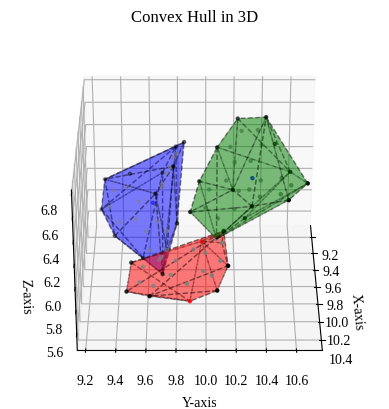

In [17]:
# Create figure and axis
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.set_title(r'Convex Hull in 3D')
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.grid(True, alpha=0.3)

# Scatter of original points
ax.scatter(points_100[:,0],
        points_100[:,1],
        points_100[:,2],
        marker='o',
        color=colors,
        s=5)

# Create the Poly3DCollection and add it to the plot
ax.add_collection3d(poly3d_1)
ax.add_collection3d(poly3d_2)
ax.add_collection3d(poly3d_3)

# Create camera rotation function
def rotate(angle):
    ax.view_init(elev=30, azim=angle)
    return fig,

# Create animation
ani = FuncAnimation(fig, rotate, frames=np.arange(0, 362, 2), interval=100, blit=True)
ani.save('./animation/[04]CH_3_Pieces_Molecule_100.mp4', writer='ffmpeg', fps=30)

# Adjust the plot view to see the whole patch
# ax.autoscale_view()
plt.show()

### 9 Small Pieces (Smallest Possible)

In [ ]:
# Obtain the 100th molecule
df_molecule_100 = df_gro.loc[(100, slice(None))]

# Create vertices array of 100th molecule
points_100 = df_molecule_100[['x', 'y', 'z']].to_numpy()

# Create pieces of the 100th molecule
piece1 = points_100[0:12]
piece2 = points_100[12:22]
piece3 = points_100[22:31]
piece4 = points_100[31:41]
piece5 = points_100[41:54]
piece6 = points_100[54:63]
piece7 = points_100[63:67]
piece8 = points_100[67:74]
piece9 = points_100[74:]

# Create convex hull
hull1 = ConvexHull(piece1, qhull_options='Qx') # Qx to avoid precision error
hull2 = ConvexHull(piece2, qhull_options='Qx')
hull3 = ConvexHull(piece3, qhull_options='Qx')
hull4 = ConvexHull(piece4, qhull_options='Qx')
hull5 = ConvexHull(piece5, qhull_options='Qx')
hull6 = ConvexHull(piece6, qhull_options='Qx')
hull7 = ConvexHull(piece7, qhull_options='Qx')
hull8 = ConvexHull(piece8, qhull_options='Qx')
hull9 = ConvexHull(piece9, qhull_options='Qx')

# Create hull_faces for Poly3DCollection
hull_faces1 = []
hull_faces2 = []
hull_faces3 = []
hull_faces4 = []
hull_faces5 = []
hull_faces6 = []
hull_faces7 = []
hull_faces8 = []
hull_faces9 = []

for simplex in hull1.simplices:
    hull_faces1.append(piece1[simplex]) # Each simplex is a triangle face
for simplex in hull2.simplices:
    hull_faces2.append(piece2[simplex])
for simplex in hull3.simplices:
    hull_faces3.append(piece3[simplex])
for simplex in hull4.simplices:
    hull_faces4.append(piece4[simplex])
for simplex in hull5.simplices:
    hull_faces5.append(piece5[simplex])
for simplex in hull6.simplices:
    hull_faces6.append(piece6[simplex])
for simplex in hull7.simplices:
    hull_faces7.append(piece7[simplex])
for simplex in hull8.simplices:
    hull_faces8.append(piece8[simplex])
for simplex in hull9.simplices:
    hull_faces9.append(piece9[simplex])

# Optional: Color faces based on their index
# colors1 = plt.cm.viridis(np.linspace(0, 1, len(hull_faces1)))
# colors2 = plt.cm.viridis(np.linspace(0, 1, len(hull_faces2)))
# colors3 = plt.cm.viridis(np.linspace(0, 1, len(hull_faces3)))

# Create a poly3d collection for plotting
poly3d_1 = Poly3DCollection(hull_faces1,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='green',
                          label='Piece 1')
poly3d_2 = Poly3DCollection(hull_faces2,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='red',
                          label='Piece 2')
poly3d_3 = Poly3DCollection(hull_faces3,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='blue')
poly3d_4 = Poly3DCollection(hull_faces4,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='orange',
                          label='Piece 4')
poly3d_5 = Poly3DCollection(hull_faces5,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='purple',
                          label='Piece 5')
poly3d_6 = Poly3DCollection(hull_faces6,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='pink',
                          label='Piece 6')
poly3d_7 = Poly3DCollection(hull_faces7,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='brown',
                          label='Piece 7')
poly3d_8 = Poly3DCollection(hull_faces8,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='cyan',
                          label='Piece 8')
poly3d_9 = Poly3DCollection(hull_faces9,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='yellow',
                          label='Piece 9')

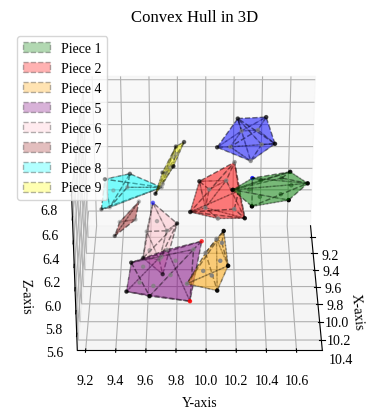

In [19]:
# Create figure and axis
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.set_title(r'Convex Hull in 3D')
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.grid(True, alpha=0.3)

# Scatter of original points
ax.scatter(points_100[:,0],
        points_100[:,1],
        points_100[:,2],
        marker='o',
        color=colors,
        s=5)

# Create the Poly3DCollection and add it to the plot
ax.add_collection3d(poly3d_1)
ax.add_collection3d(poly3d_2)
ax.add_collection3d(poly3d_3)
ax.add_collection3d(poly3d_4)
ax.add_collection3d(poly3d_5)
ax.add_collection3d(poly3d_6)
ax.add_collection3d(poly3d_7)
ax.add_collection3d(poly3d_8)
ax.add_collection3d(poly3d_9)

# Show legend
ax.legend(loc='upper left')

# Create camera rotation function
def rotate(angle):
    ax.view_init(elev=30, azim=angle)
    return fig,

# Create animation
ani = FuncAnimation(fig, rotate, frames=np.arange(0, 362, 2), interval=100, blit=True)
ani.save('./animation/[05]CH_9_Pieces_Molecule_100.mp4', writer='ffmpeg', fps=30)

# Adjust the plot view to see the whole patch
# ax.autoscale_view()
plt.show()

### 11 Small Pieces (Selected)

In [20]:
# Obtain the 100th molecule
df_molecule_100 = df_gro.loc[(100, slice(None))]

# Create vertices array of 100th molecule
points_100 = df_molecule_100[['x', 'y', 'z']].to_numpy()

# Select atoms at specific indices
indices_1 = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
indices_2 = [12, 13, 14, 15, 16, 17, 18, 19, 20]
indices_3 = [21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
indices_4 = [11, 12, 20, 21, 22]
indices_5 = [31, 32, 33, 34, 35, 36, 37, 38, 39]
indices_6 = [32, 33, 40, 41, 42, 50, 51, 52]
indices_7 = [42, 41, 43, 44, 45, 46, 47, 48, 49, 50] 
indices_8 = [53, 54, 55, 56, 57, 58, 59, 60, 61, 62] 
indices_9 = [58, 59, 62, 63, 64]
indices_10 = [63, 64, 65, 66, 67, 68, 69, 70, 71, 72]
indices_11 = [73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83]

# Create pieces of the 100th molecule
piece1 = points_100[indices_1]
piece2 = points_100[indices_2]
piece3 = points_100[indices_3]
piece4 = points_100[indices_4]
piece5 = points_100[indices_5]
piece6 = points_100[indices_6]
piece7 = points_100[indices_7]
piece8 = points_100[indices_8]
piece9 = points_100[indices_9]
piece10 = points_100[indices_10]
piece11 = points_100[indices_11]

# Create convex hull
hull1 = ConvexHull(piece1, qhull_options='Qx') # Qx to avoid precision error
hull2 = ConvexHull(piece2, qhull_options='Qx')
hull3 = ConvexHull(piece3, qhull_options='Qx')
hull4 = ConvexHull(piece4, qhull_options='Qx')
hull5 = ConvexHull(piece5, qhull_options='Qx')
hull6 = ConvexHull(piece6, qhull_options='Qx')
hull7 = ConvexHull(piece7, qhull_options='Qx')
hull8 = ConvexHull(piece8, qhull_options='Qx')
hull9 = ConvexHull(piece9, qhull_options='Qx')
hull10 = ConvexHull(piece10, qhull_options='Qx')
hull11 = ConvexHull(piece11, qhull_options='Qx')

# Create hull_faces for Poly3DCollection
hull_faces1 = []
hull_faces2 = []
hull_faces3 = []
hull_faces4 = []
hull_faces5 = []
hull_faces6 = []
hull_faces7 = []
hull_faces8 = []
hull_faces9 = []
hull_faces10 = []
hull_faces11 = []

for simplex in hull1.simplices:
    hull_faces1.append(piece1[simplex]) # Each simplex is a triangle face
for simplex in hull2.simplices:
    hull_faces2.append(piece2[simplex])
for simplex in hull3.simplices:
    hull_faces3.append(piece3[simplex])
for simplex in hull4.simplices:
    hull_faces4.append(piece4[simplex])
for simplex in hull5.simplices:
    hull_faces5.append(piece5[simplex])
for simplex in hull6.simplices:
    hull_faces6.append(piece6[simplex])
for simplex in hull7.simplices:
    hull_faces7.append(piece7[simplex])
for simplex in hull8.simplices:
    hull_faces8.append(piece8[simplex])
for simplex in hull9.simplices:
    hull_faces9.append(piece9[simplex])
for simplex in hull10.simplices:
    hull_faces10.append(piece10[simplex])
for simplex in hull11.simplices:
    hull_faces11.append(piece11[simplex])

# Optional: Color faces based on their index
# colors1 = plt.cm.viridis(np.linspace(0, 1, len(hull_faces1)))
# colors2 = plt.cm.viridis(np.linspace(0, 1, len(hull_faces2)))
# colors3 = plt.cm.viridis(np.linspace(0, 1, len(hull_faces3)))

# Create a poly3d collection for plotting
poly3d_1 = Poly3DCollection(hull_faces1,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='green',
                          label='Piece 1')
poly3d_2 = Poly3DCollection(hull_faces2,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='red',
                          label='Piece 2')
poly3d_3 = Poly3DCollection(hull_faces3,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='blue')
poly3d_4 = Poly3DCollection(hull_faces4,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='orange',
                          label='Piece 4')
poly3d_5 = Poly3DCollection(hull_faces5,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='purple',
                          label='Piece 5')
poly3d_6 = Poly3DCollection(hull_faces6,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='pink',
                          label='Piece 6')
poly3d_7 = Poly3DCollection(hull_faces7,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='brown',
                          label='Piece 7')
poly3d_8 = Poly3DCollection(hull_faces8,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='cyan',
                          label='Piece 8')
poly3d_9 = Poly3DCollection(hull_faces9,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='yellow',
                          label='Piece 9')
poly3d_10 = Poly3DCollection(hull_faces10,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='magenta',
                          label='Piece 10')
poly3d_11 = Poly3DCollection(hull_faces11,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='lime',
                          label='Piece 11')

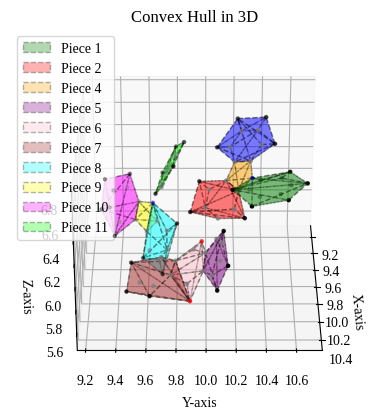

In [21]:
# Create figure and axis
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.set_title(r'Convex Hull in 3D')
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.grid(True, alpha=0.3)

# Scatter of original points
ax.scatter(points_100[:,0],
        points_100[:,1],
        points_100[:,2],
        marker='o',
        color=colors,
        s=5)

# Create the Poly3DCollection and add it to the plot
ax.add_collection3d(poly3d_1)
ax.add_collection3d(poly3d_2)
ax.add_collection3d(poly3d_3)
ax.add_collection3d(poly3d_4)
ax.add_collection3d(poly3d_5)
ax.add_collection3d(poly3d_6)
ax.add_collection3d(poly3d_7)
ax.add_collection3d(poly3d_8)
ax.add_collection3d(poly3d_9)
ax.add_collection3d(poly3d_10)
ax.add_collection3d(poly3d_11)

# Show legend
ax.legend(loc='upper left')

# Create camera rotation function
def rotate(angle):
    ax.view_init(elev=30, azim=angle)
    return fig,

# Create animation
ani = FuncAnimation(fig, rotate, frames=np.arange(0, 362, 2), interval=100, blit=True)
ani.save('./animation/[06]CH_11_Selected_Pieces_Molecule_100.mp4', writer='ffmpeg', fps=30)

# Adjust the plot view to see the whole patch
# ax.autoscale_view()
plt.show()

### 11 Piece Final Adjustment

In [22]:
# Obtain the 100th molecule
df_molecule_100 = df_gro.loc[(100, slice(None))]

# Create vertices array of 100th molecule
points_100 = df_molecule_100[['x', 'y', 'z']].to_numpy()

# Select atoms at specific indices
indices_1 = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
indices_2 = [12, 13, 14, 15, 16, 17, 18, 19, 20]
indices_3 = [21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
indices_4 = [11, 12, 20, 21, 22]
indices_5 = [16, 31, 32, 33, 34, 35, 36, 37, 38, 39]
indices_6 = [32, 33, 40, 41, 42, 50, 51, 52]
indices_7 = [42, 43, 44, 45, 46, 47, 48, 49, 50, 54] 
indices_8 = [53, 54, 55, 56, 57, 58, 59, 60, 61, 62] 
indices_9 = [58, 59, 62, 63, 64]
indices_10 = [63, 64, 65, 66, 67, 68, 69, 70, 71, 72]
indices_11 = [62, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83]

# Create pieces of the 100th molecule
piece1 = points_100[indices_1]
piece2 = points_100[indices_2]
piece3 = points_100[indices_3]
piece4 = points_100[indices_4]
piece5 = points_100[indices_5]
piece6 = points_100[indices_6]
piece7 = points_100[indices_7]
piece8 = points_100[indices_8]
piece9 = points_100[indices_9]
piece10 = points_100[indices_10]
piece11 = points_100[indices_11]

# Create convex hull
hull1 = ConvexHull(piece1, qhull_options='Qx') # Qx to avoid precision error
hull2 = ConvexHull(piece2, qhull_options='Qx')
hull3 = ConvexHull(piece3, qhull_options='Qx')
hull4 = ConvexHull(piece4, qhull_options='Qx')
hull5 = ConvexHull(piece5, qhull_options='Qx')
hull6 = ConvexHull(piece6, qhull_options='Qx')
hull7 = ConvexHull(piece7, qhull_options='Qx')
hull8 = ConvexHull(piece8, qhull_options='Qx')
hull9 = ConvexHull(piece9, qhull_options='Qx')
hull10 = ConvexHull(piece10, qhull_options='Qx')
hull11 = ConvexHull(piece11, qhull_options='Qx')

# Create hull_faces for Poly3DCollection
hull_faces1 = []
hull_faces2 = []
hull_faces3 = []
hull_faces4 = []
hull_faces5 = []
hull_faces6 = []
hull_faces7 = []
hull_faces8 = []
hull_faces9 = []
hull_faces10 = []
hull_faces11 = []

for simplex in hull1.simplices:
    hull_faces1.append(piece1[simplex]) # Each simplex is a triangle face
for simplex in hull2.simplices:
    hull_faces2.append(piece2[simplex])
for simplex in hull3.simplices:
    hull_faces3.append(piece3[simplex])
for simplex in hull4.simplices:
    hull_faces4.append(piece4[simplex])
for simplex in hull5.simplices:
    hull_faces5.append(piece5[simplex])
for simplex in hull6.simplices:
    hull_faces6.append(piece6[simplex])
for simplex in hull7.simplices:
    hull_faces7.append(piece7[simplex])
for simplex in hull8.simplices:
    hull_faces8.append(piece8[simplex])
for simplex in hull9.simplices:
    hull_faces9.append(piece9[simplex])
for simplex in hull10.simplices:
    hull_faces10.append(piece10[simplex])
for simplex in hull11.simplices:
    hull_faces11.append(piece11[simplex])

# Optional: Color faces based on their index
# colors1 = plt.cm.viridis(np.linspace(0, 1, len(hull_faces1)))
# colors2 = plt.cm.viridis(np.linspace(0, 1, len(hull_faces2)))
# colors3 = plt.cm.viridis(np.linspace(0, 1, len(hull_faces3)))

# Create a poly3d collection for plotting
poly3d_1 = Poly3DCollection(hull_faces1,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='green',
                          label='Piece 1')
poly3d_2 = Poly3DCollection(hull_faces2,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='red',
                          label='Piece 2')
poly3d_3 = Poly3DCollection(hull_faces3,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='blue')
poly3d_4 = Poly3DCollection(hull_faces4,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='orange',
                          label='Piece 4')
poly3d_5 = Poly3DCollection(hull_faces5,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='purple',
                          label='Piece 5')
poly3d_6 = Poly3DCollection(hull_faces6,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='pink',
                          label='Piece 6')
poly3d_7 = Poly3DCollection(hull_faces7,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='brown',
                          label='Piece 7')
poly3d_8 = Poly3DCollection(hull_faces8,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='cyan',
                          label='Piece 8')
poly3d_9 = Poly3DCollection(hull_faces9,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='yellow',
                          label='Piece 9')
poly3d_10 = Poly3DCollection(hull_faces10,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='magenta',
                          label='Piece 10')
poly3d_11 = Poly3DCollection(hull_faces11,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='lime',
                          label='Piece 11')

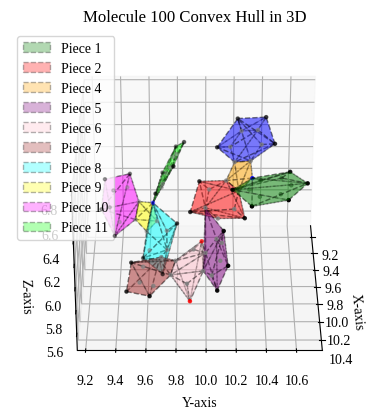

In [23]:
# Create figure and axis
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.set_title(r'Molecule 100 Convex Hull in 3D')
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.grid(True, alpha=0.3)

# Scatter of original points
ax.scatter(points_100[:,0],
        points_100[:,1],
        points_100[:,2],
        marker='o',
        color=colors,
        s=5)

# Create the Poly3DCollection and add it to the plot
ax.add_collection3d(poly3d_1)
ax.add_collection3d(poly3d_2)
ax.add_collection3d(poly3d_3)
ax.add_collection3d(poly3d_4)
ax.add_collection3d(poly3d_5)
ax.add_collection3d(poly3d_6)
ax.add_collection3d(poly3d_7)
ax.add_collection3d(poly3d_8)
ax.add_collection3d(poly3d_9)
ax.add_collection3d(poly3d_10)
ax.add_collection3d(poly3d_11)

# Show legend
ax.legend(loc='upper left')

# Create camera rotation function
def rotate(angle):
    ax.view_init(elev=30, azim=angle)
    return fig,

# Create animation
ani = FuncAnimation(fig, rotate, frames=np.arange(0, 362, 2), interval=100, blit=True)
ani.save('./animation/[07]CH_11_Adjusted_Selected_Pieces_Molecule_100.mp4', writer='ffmpeg', fps=30)

# Adjust the plot view to see the whole patch
# ax.autoscale_view()
plt.show()

---

## 3. Testing on Other Oxygen Molecules

In [24]:
# Obtain the 101st molecule
df_molecule_101 = df_gro.loc[(101, slice(None))]
# Obtain the 200th molecule
df_molecule_200 = df_gro.loc[(200, slice(None))]

# Extract first character of each atom name
df_first_chars = df_molecule_101.index.str[0]

# Color mapping dictionary
color_map = {
    'H': 'black',
    'N': 'blue',
    'C': 'gray',
    'O': 'red',
}

# Use map to assign colors based of first character
colors = df_first_chars.map(color_map).to_numpy()

Molecule 101

In [25]:
# Create vertices array of 101st molecule
points_101 = df_molecule_101[['x', 'y', 'z']].to_numpy()

# Select atoms at specific indices
indices_1 = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
indices_2 = [12, 13, 14, 15, 16, 17, 18, 19, 20]
indices_3 = [21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
indices_4 = [11, 12, 20, 21, 22]
indices_5 = [16, 31, 32, 33, 34, 35, 36, 37, 38, 39]
indices_6 = [32, 33, 40, 41, 42, 50, 51, 52]
indices_7 = [42, 43, 44, 45, 46, 47, 48, 49, 50, 54] 
indices_8 = [53, 54, 55, 56, 57, 58, 59, 60, 61, 62] 
indices_9 = [58, 59, 62, 63, 64]
indices_10 = [63, 64, 65, 66, 67, 68, 69, 70, 71, 72]
indices_11 = [62, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83]

# Create pieces of the 101st molecule
piece1 = points_101[indices_1]
piece2 = points_101[indices_2]
piece3 = points_101[indices_3]
piece4 = points_101[indices_4]
piece5 = points_101[indices_5]
piece6 = points_101[indices_6]
piece7 = points_101[indices_7]
piece8 = points_101[indices_8]
piece9 = points_101[indices_9]
piece10 = points_101[indices_10]
piece11 = points_101[indices_11]

# Create convex hull
hull1 = ConvexHull(piece1, qhull_options='Qx') # Qx to avoid precision error
hull2 = ConvexHull(piece2, qhull_options='Qx')
hull3 = ConvexHull(piece3, qhull_options='Qx')
hull4 = ConvexHull(piece4, qhull_options='Qx')
hull5 = ConvexHull(piece5, qhull_options='Qx')
hull6 = ConvexHull(piece6, qhull_options='Qx')
hull7 = ConvexHull(piece7, qhull_options='Qx')
hull8 = ConvexHull(piece8, qhull_options='Qx')
hull9 = ConvexHull(piece9, qhull_options='Qx')
hull10 = ConvexHull(piece10, qhull_options='Qx')
hull11 = ConvexHull(piece11, qhull_options='Qx')

# Create hull_faces for Poly3DCollection
hull_faces1 = []
hull_faces2 = []
hull_faces3 = []
hull_faces4 = []
hull_faces5 = []
hull_faces6 = []
hull_faces7 = []
hull_faces8 = []
hull_faces9 = []
hull_faces10 = []
hull_faces11 = []

for simplex in hull1.simplices:
    hull_faces1.append(piece1[simplex]) # Each simplex is a triangle face
for simplex in hull2.simplices:
    hull_faces2.append(piece2[simplex])
for simplex in hull3.simplices:
    hull_faces3.append(piece3[simplex])
for simplex in hull4.simplices:
    hull_faces4.append(piece4[simplex])
for simplex in hull5.simplices:
    hull_faces5.append(piece5[simplex])
for simplex in hull6.simplices:
    hull_faces6.append(piece6[simplex])
for simplex in hull7.simplices:
    hull_faces7.append(piece7[simplex])
for simplex in hull8.simplices:
    hull_faces8.append(piece8[simplex])
for simplex in hull9.simplices:
    hull_faces9.append(piece9[simplex])
for simplex in hull10.simplices:
    hull_faces10.append(piece10[simplex])
for simplex in hull11.simplices:
    hull_faces11.append(piece11[simplex])

# Optional: Color faces based on their index
# colors1 = plt.cm.viridis(np.linspace(0, 1, len(hull_faces1)))
# colors2 = plt.cm.viridis(np.linspace(0, 1, len(hull_faces2)))
# colors3 = plt.cm.viridis(np.linspace(0, 1, len(hull_faces3)))

# Create a poly3d collection for plotting
poly3d_1 = Poly3DCollection(hull_faces1,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='green',
                          label='Piece 1')
poly3d_2 = Poly3DCollection(hull_faces2,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='red',
                          label='Piece 2')
poly3d_3 = Poly3DCollection(hull_faces3,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='blue')
poly3d_4 = Poly3DCollection(hull_faces4,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='orange',
                          label='Piece 4')
poly3d_5 = Poly3DCollection(hull_faces5,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='purple',
                          label='Piece 5')
poly3d_6 = Poly3DCollection(hull_faces6,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='pink',
                          label='Piece 6')
poly3d_7 = Poly3DCollection(hull_faces7,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='brown',
                          label='Piece 7')
poly3d_8 = Poly3DCollection(hull_faces8,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='cyan',
                          label='Piece 8')
poly3d_9 = Poly3DCollection(hull_faces9,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='yellow',
                          label='Piece 9')
poly3d_10 = Poly3DCollection(hull_faces10,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='magenta',
                          label='Piece 10')
poly3d_11 = Poly3DCollection(hull_faces11,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='lime',
                          label='Piece 11')

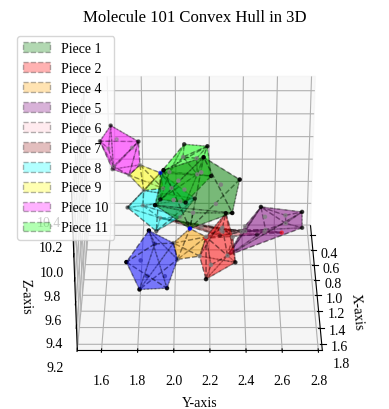

In [26]:
# Create figure and axis
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.set_title(r'Molecule 101 Convex Hull in 3D')
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.grid(True, alpha=0.3)

# Scatter of original points
ax.scatter(points_101[:,0],
        points_101[:,1],
        points_101[:,2],
        marker='o',
        color=colors,
        s=5)

# Create the Poly3DCollection and add it to the plot
ax.add_collection3d(poly3d_1)
ax.add_collection3d(poly3d_2)
ax.add_collection3d(poly3d_3)
ax.add_collection3d(poly3d_4)
ax.add_collection3d(poly3d_5)
ax.add_collection3d(poly3d_6)
ax.add_collection3d(poly3d_7)
ax.add_collection3d(poly3d_8)
ax.add_collection3d(poly3d_9)
ax.add_collection3d(poly3d_10)
ax.add_collection3d(poly3d_11)

# Show legend
ax.legend(loc='upper left')

# Create camera rotation function
def rotate(angle):
    ax.view_init(elev=30, azim=angle)
    return fig,

# Create animation
ani = FuncAnimation(fig, rotate, frames=np.arange(0, 362, 2), interval=100, blit=True)
ani.save('./animation/[08]CH_11_Adjusted_Selected_Pieces_Molecule_101.mp4', writer='ffmpeg', fps=30)

# Adjust the plot view to see the whole patch
# ax.autoscale_view()
plt.show()

Molecule 200

In [29]:
# Create vertices array of 200th molecule
points_200 = df_molecule_200[['x', 'y', 'z']].to_numpy()

# Select atoms at specific indices
indices_1 = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
indices_2 = [12, 13, 14, 15, 16, 17, 18, 19, 20]
indices_3 = [21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
indices_4 = [11, 12, 20, 21, 22]
indices_5 = [16, 31, 32, 33, 34, 35, 36, 37, 38, 39]
indices_6 = [32, 33, 40, 41, 42, 50, 51, 52]
indices_7 = [42, 43, 44, 45, 46, 47, 48, 49, 50, 54] 
indices_8 = [53, 54, 55, 56, 57, 58, 59, 60, 61, 62] 
indices_9 = [58, 59, 62, 63, 64]
indices_10 = [63, 64, 65, 66, 67, 68, 69, 70, 71, 72]
indices_11 = [62, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83]

# Create pieces of the 101st molecule
piece1 = points_200[indices_1]
piece2 = points_200[indices_2]
piece3 = points_200[indices_3]
piece4 = points_200[indices_4]
piece5 = points_200[indices_5]
piece6 = points_200[indices_6]
piece7 = points_200[indices_7]
piece8 = points_200[indices_8]
piece9 = points_200[indices_9]
piece10 = points_200[indices_10]
piece11 = points_200[indices_11]

# Create convex hull
hull1 = ConvexHull(piece1, qhull_options='Qx') # Qx to avoid precision error
hull2 = ConvexHull(piece2, qhull_options='Qx')
hull3 = ConvexHull(piece3, qhull_options='Qx')
hull4 = ConvexHull(piece4, qhull_options='Qx')
hull5 = ConvexHull(piece5, qhull_options='Qx')
hull6 = ConvexHull(piece6, qhull_options='Qx')
hull7 = ConvexHull(piece7, qhull_options='Qx')
hull8 = ConvexHull(piece8, qhull_options='Qx')
hull9 = ConvexHull(piece9, qhull_options='Qx')
hull10 = ConvexHull(piece10, qhull_options='Qx')
hull11 = ConvexHull(piece11, qhull_options='Qx')

# Create hull_faces for Poly3DCollection
hull_faces1 = []
hull_faces2 = []
hull_faces3 = []
hull_faces4 = []
hull_faces5 = []
hull_faces6 = []
hull_faces7 = []
hull_faces8 = []
hull_faces9 = []
hull_faces10 = []
hull_faces11 = []

for simplex in hull1.simplices:
    hull_faces1.append(piece1[simplex]) # Each simplex is a triangle face
for simplex in hull2.simplices:
    hull_faces2.append(piece2[simplex])
for simplex in hull3.simplices:
    hull_faces3.append(piece3[simplex])
for simplex in hull4.simplices:
    hull_faces4.append(piece4[simplex])
for simplex in hull5.simplices:
    hull_faces5.append(piece5[simplex])
for simplex in hull6.simplices:
    hull_faces6.append(piece6[simplex])
for simplex in hull7.simplices:
    hull_faces7.append(piece7[simplex])
for simplex in hull8.simplices:
    hull_faces8.append(piece8[simplex])
for simplex in hull9.simplices:
    hull_faces9.append(piece9[simplex])
for simplex in hull10.simplices:
    hull_faces10.append(piece10[simplex])
for simplex in hull11.simplices:
    hull_faces11.append(piece11[simplex])

# Optional: Color faces based on their index
# colors1 = plt.cm.viridis(np.linspace(0, 1, len(hull_faces1)))
# colors2 = plt.cm.viridis(np.linspace(0, 1, len(hull_faces2)))
# colors3 = plt.cm.viridis(np.linspace(0, 1, len(hull_faces3)))

# Create a poly3d collection for plotting
poly3d_1 = Poly3DCollection(hull_faces1,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='green',
                          label='Piece 1')
poly3d_2 = Poly3DCollection(hull_faces2,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='red',
                          label='Piece 2')
poly3d_3 = Poly3DCollection(hull_faces3,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='blue')
poly3d_4 = Poly3DCollection(hull_faces4,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='orange',
                          label='Piece 4')
poly3d_5 = Poly3DCollection(hull_faces5,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='purple',
                          label='Piece 5')
poly3d_6 = Poly3DCollection(hull_faces6,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='pink',
                          label='Piece 6')
poly3d_7 = Poly3DCollection(hull_faces7,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='brown',
                          label='Piece 7')
poly3d_8 = Poly3DCollection(hull_faces8,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='cyan',
                          label='Piece 8')
poly3d_9 = Poly3DCollection(hull_faces9,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='yellow',
                          label='Piece 9')
poly3d_10 = Poly3DCollection(hull_faces10,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='magenta',
                          label='Piece 10')
poly3d_11 = Poly3DCollection(hull_faces11,
                          alpha=0.3, 
                          ls='--', 
                          linewidth=1,
                          edgecolor='k',
                          facecolor='lime',
                          label='Piece 11')

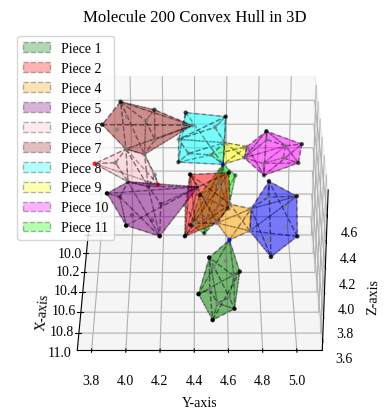

In [30]:
# Create figure and axis
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.set_title(r'Molecule 200 Convex Hull in 3D')
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.grid(True, alpha=0.3)

# Scatter of original points
ax.scatter(points_200[:,0],
        points_200[:,1],
        points_200[:,2],
        marker='o',
        color=colors,
        s=5)

# Create the Poly3DCollection and add it to the plot
ax.add_collection3d(poly3d_1)
ax.add_collection3d(poly3d_2)
ax.add_collection3d(poly3d_3)
ax.add_collection3d(poly3d_4)
ax.add_collection3d(poly3d_5)
ax.add_collection3d(poly3d_6)
ax.add_collection3d(poly3d_7)
ax.add_collection3d(poly3d_8)
ax.add_collection3d(poly3d_9)
ax.add_collection3d(poly3d_10)
ax.add_collection3d(poly3d_11)

# Show legend
ax.legend(loc='upper left')

# Create camera rotation function
def rotate(angle):
    ax.view_init(elev=30, azim=angle)
    return fig,

# Create animation
ani = FuncAnimation(fig, rotate, frames=np.arange(0, 362, 2), interval=100, blit=True)
ani.save('./animation/[09]CH_11_Adjusted_Selected_Pieces_Molecule_200.mp4', writer='ffmpeg', fps=30)

# Adjust the plot view to see the whole patch
# ax.autoscale_view()
plt.show()

---

# Image Resizer

In [ ]:
from PIL import Image

# Parameters
input_path = 'ConvexHull2D.png'
output_path = 'ConvexHull2D_resized.png'
percentage = 80

# Open the image file
with Image.open(input_path) as img:
    # Get the original width and height
    width, height = img.size
    
    # Calculate the new dimensions
    new_width = int(width * (percentage / 100))
    new_height = int(height * (percentage / 100))
    
    # Resize the image using the new dimensions
    resized_img = img.resize((new_width, new_height))
    
    # Save the resized image
    resized_img.save(output_path)
    
    print(f"Image resized to {percentage}% and saved to {output_path}")

Image resized to 80% and saved to ConvexHull2D_resized.png
